# NumPy for Reaction Engineering

This notebook introduces NumPy through examples that are directly useful in chemical reaction engineering.

The focus is on:
- representing reaction data as arrays
- performing vectorized calculations
- handling concentration, conversion, and rate profiles
- preparing for reactor modeling and parameter estimation

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Why NumPy matters in reaction engineering

Reaction engineering often deals with data such as:

- time
- concentration
- conversion
- temperature
- rate

These quantities are usually measured at many points, not just one value. NumPy lets us store and manipulate them efficiently.

Example

A batch reactor concentration profile can be represented as an array:

In [2]:
t = np.array([0, 5, 10, 15, 20])
CA = np.array([1.00, 0.82, 0.67, 0.55, 0.45])

t, CA

(array([ 0,  5, 10, 15, 20]), array([1.  , 0.82, 0.67, 0.55, 0.45]))

## 2. Arrays as reaction data

### 2.1 One-dimensional arrays

One-dimensional arrays are useful for:

- time points
- concentration values
- conversion values
- rate values

In [ ]:
t = np.array([0, 1, 2, 3, 4, 5])

### 2.2 Two-dimensional arrays

Two-dimensional arrays are useful for:

- multiple experiments
- multiple species
- experimental data tables

In [3]:
experimental_data = np.array([
    [0, 1.00],
    [5, 0.82],
    [10, 0.67],
    [15, 0.55],
    [20, 0.45]
])

experimental_data

array([[ 0.  ,  1.  ],
       [ 5.  ,  0.82],
       [10.  ,  0.67],
       [15.  ,  0.55],
       [20.  ,  0.45]])

## 3. Basic array operations

### 3.1 Create arrays

In [ ]:
A = np.array([1, 2, 3])
B = np.array([4, 5, 6])

(array([5, 7, 9]), array([ 4, 10, 18]), array([1, 4, 9]))

### 3.2 Elementwise operations

In [ ]:

A + B, A * B, A ** 2

### 3.3 Indexing and slicing

In [ ]:
CA[0]
CA[-1]
CA[1:4]

### 3.4 Boolean filtering

In [ ]:
CA[CA < 0.7]

This is useful when selecting data points below a threshold.

## 4. Concentration profiles as arrays

### 4.1 First order batch reaction

For a simple first-order reaction:
$$
-\frac{dC_A}{dt}=kC_A
$$

The analytical solution is:
$$
C_A(t)=C_{A0}e^{-kt}
$$

### 4.2 Compute concentration profile

In [ ]:
k = 0.12
CA0 = 1.0
t = np.linspace(0, 30, 200)
CA = CA0 * np.exp(-k * t)


### 4.3 Compute conversion profile

For batch system:
$$
X=\frac{C_{A0}-C_A}{C_{A0}}
$$

In [ ]:
X = (CA0 - CA) / CA0

### 4.4 Plot concentration and conversion

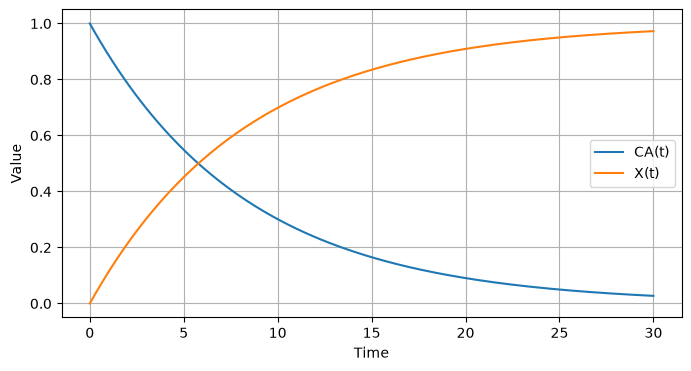

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(t, CA, label='CA(t)')
plt.plot(t, X, label='X(t)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

## 5. Rate laws in vector form

### 5.1 First-order rate law

In [ ]:
rA = -k * CA


### 5.2 Second-order rate law

In [ ]:
k2 = 0.08
rA2 = -k2 * CA**2

### 5.3 Compare different rate laws

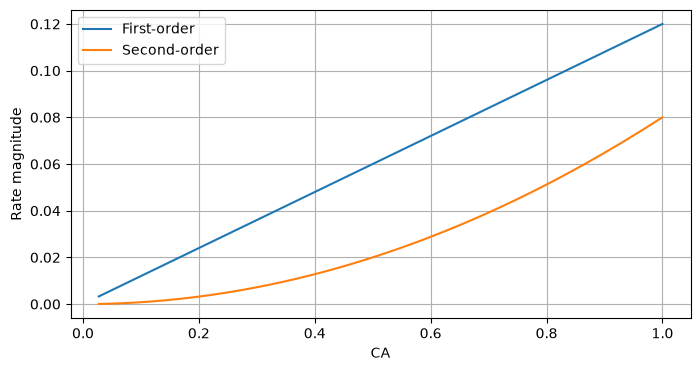

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(CA, -rA, label='First-order')
plt.plot(CA, -rA2, label='Second-order')
plt.xlabel('CA')
plt.ylabel('Rate magnitude')
plt.legend()
plt.grid(True)
plt.show()

## 6. Stoichiometry with arrays

### 6.1 Simple reaction

Consider:
$$
A\rightarrow{B}
$$

If A is consumed and B is formed, then:

In [9]:
CA = np.array([1.0, 0.8, 0.6, 0.4])
CB = 1.0 - CA
CB

array([0. , 0.2, 0.4, 0.6])

### 6.2 More general idea

For a reaction network, arrays can store the concentration of each species at each time point.

In [ ]:
species_data = np.array([
    [1.00, 0.00],
    [0.80, 0.20],
    [0.60, 0.40],
    [0.40, 0.60]
])

## 7. Experimental data handling

### 7.1 Create a small dataset

In [ ]:
time = np.array([0, 5, 10, 15, 20])
conc = np.array([1.00, 0.82, 0.67, 0.55, 0.45])


(array([ 0,  5, 10]), array([1.  , 0.82, 0.67]))

### 7.2 Select useful data points

In [ ]:
mask = conc > 0.6
selected_time = time[mask]
selected_conc = conc[mask]
selected_time, selected_conc

### 7.3 Combine data into a table-like array

In [ ]:
data = np.column_stack((time, conc))

## 8. Mini case study: batch reaction data

Suppose we have batch reactor measurements for species A.

### Task 1: compute conversion

In [ ]:
CA0 = conc[0]
X = (CA0 - conc) / CA0
X

### Task 2: estimate instantaneous rate using finite differences

In [ ]:
rate_est = -np.diff(conc) / np.diff(time)
rate_est

### Task 3: plot the results

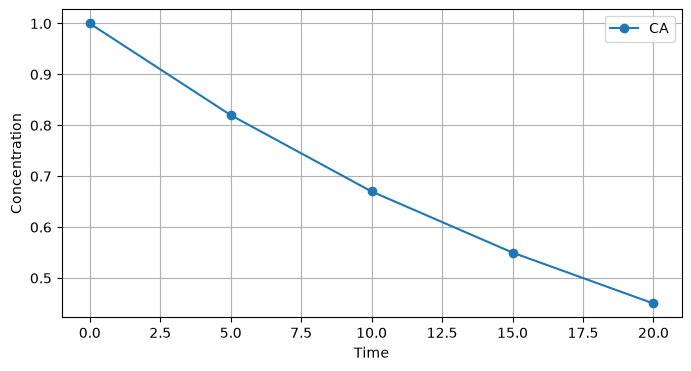

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(time, conc, marker='o', label='CA')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.grid(True)
plt.legend()
plt.show()

## 9. Summary

In this notebook, you learned how to:
- store reaction engineering data in NumPy arrays
- perform vectorized calculations
- represent concentration and conversion profiles
- compute rates from concentration data
- prepare data for reactor design and kinetic analysis